# Entregável 8: Redução de Dimensionalidade
**Disciplina:** Aquisição de Biossinais
**Equipe:** José Ferreira Lessa e Matheus Rocha Gomes da Silva
**Objetivo:** Reduzir o espaço de features para um conjunto de componentes não correlacionados que retém a maior parte da variância, facilitando a visualização, reduzindo o custo computacional e revelando estrutura latente. Ao final testaremos também o ICA para segregação de fontes independentes.

## 1. Importações e Dependências

In [12]:
import os
import ast
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

## 2. Configurações Globais e Leitura de Dados

In [13]:
DIR_OUT_D7 = '../../entregavel-7/outputs/'
DIR_OUT_D8 = '../outputs/'
FIGS_DIR = '../figuras/'

os.makedirs(DIR_OUT_D8, exist_ok=True)
os.makedirs(FIGS_DIR, exist_ok=True)

print("Carregando features do Entregável 7...")
path_engineered = os.path.join(DIR_OUT_D7, 'features_engineered.parquet')

if not os.path.exists(path_engineered):
    raise FileNotFoundError("Arquivo features_engineered.parquet não encontrado.")

df = pd.read_parquet(path_engineered)

# Reconstruir rótulos
meta_cols = ['patient_id', 'strat_fold', 'sqi_category', 'diagnostic_superclass', 'label_primary']
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f"Dataset carregado: {df.shape[0]} instâncias, {len(feature_cols)} features.")

Carregando features do Entregável 7...
Dataset carregado: 21735 instâncias, 213 features.


---
## Seção 1 — Motivação e Dimensionalidade

### 1.1 Dimensionalidade e Maldição da Dimensionalidade
A "maldição da dimensionalidade" descreve vários problemas que surgem na análise de dados em espaços de alta dimensão. Para algoritmos baseados em distância (como kNN ou SVM), a distância entre dois pontos quaisquer converge para valores similares. Uma relação suspeita é quando `n_features >> sqrt(n_samples)`.

In [14]:
n_samples = df.shape[0]
n_features = len(feature_cols)
sqrt_n = np.sqrt(n_samples)

display(pd.DataFrame({
    'Métrica': ['Nº de Amostras (N)', 'Nº de Features (F)', 'Sqrt(N)', 'Razão F / Sqrt(N)'],
    'Valor': [n_samples, n_features, round(sqrt_n, 2), round(n_features / sqrt_n, 2)]
}))

if n_features > sqrt_n:
    print(f"Atenção: O número de features ({n_features}) é maior que a raiz das amostras ({sqrt_n:.1f}). A redução de dimensionalidade é altamente recomendada.")

display(Markdown("**(Espaço para comentário do aluno — discuta como uma proporção muito alta prejudica os modelos de vizinhança na sua análise clínica).**"))

,Métrica,Valor
0,Nº de Amostras (N),21735.00
1,Nº de Features (F),213.00
2,Sqrt(N),147.43
3,Razão F / Sqrt(N),1.44


Atenção: O número de features (213) é maior que a raiz das amostras (147.4). A redução de dimensionalidade é altamente recomendada.


**(Espaço para comentário do aluno — discuta como uma proporção muito alta prejudica os modelos de vizinhança na sua análise clínica).**

---
## Seção 2 — PCA (Principal Component Analysis)

O PCA encontra direções ortogonais de máxima variância no dataset. Para evitar Data Leakage, todo `fit` será feito **exclusivamente com os folds de treino (1–8)**.

### 2.1 Separação Treino/Teste e Padronização Prévia ao PCA
O PCA é sensível à escala. Embora já tenhamos utilizado o RobustScaler, iremos padronizar novamente com `StandardScaler` para garantir variância estritamente unitária e focar na correlação (este passo ajuda algoritmos SVD).

In [15]:
# Máscaras de Split
treino_mask = df['strat_fold'].isin([1, 2, 3, 4, 5, 6, 7, 8])

X_treino_raw = df.loc[treino_mask, feature_cols].values
X_all_raw = df[feature_cols].values

print("Ajustando StandardScaler (apenas nos folds de Treino)...")
scaler_pca = StandardScaler()
X_treino_std = scaler_pca.fit_transform(X_treino_raw)
X_all_std = scaler_pca.transform(X_all_raw)

Ajustando StandardScaler (apenas nos folds de Treino)...


### 2.2 Ajuste e Análise do PCA (Variância)
Faremos o fit inicial com todos os componentes limitados ao número de dimensões (`n_components=None`), que neste caso equivale ao próprio `n_features`.

Calculando o PCA completo sobre o treino...


,Variância Retida (%),Nº de PCs necessários
0,80,21
1,90,44
2,95,68
3,99,113


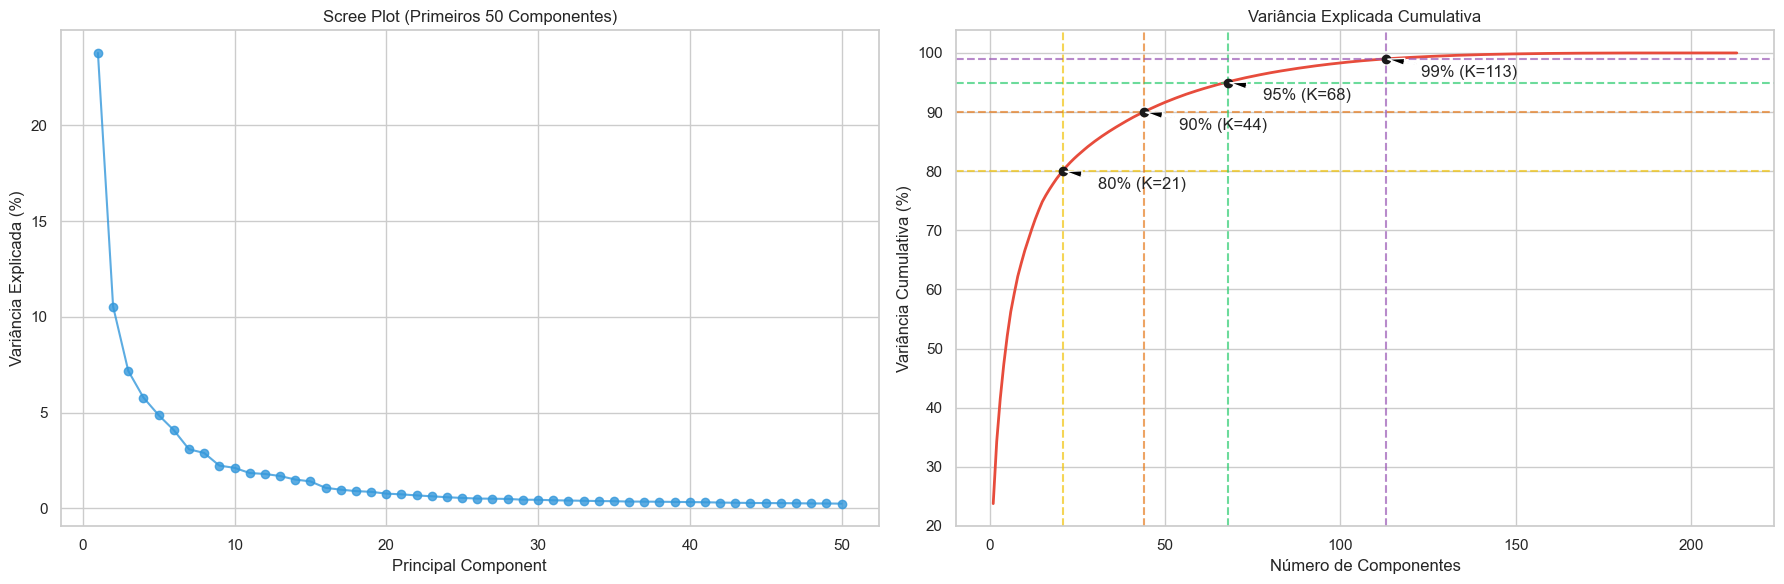

**(Espaço para comentário do aluno — Identifique onde fica o 'cotovelo' do PCA. Discuta a decisão entre Kaiser (autovalor>1) vs Acúmulo de Variância. Recomendaremos na base final 95%.)**

In [16]:
print("Calculando o PCA completo sobre o treino...")
pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(X_treino_std)

exp_var = pca_full.explained_variance_ratio_ * 100
cum_var = np.cumsum(exp_var)

# Limiares de variância e cálculo de cortes
limiares = [80, 90, 95, 99]
cortes_k = {lim: np.argmax(cum_var >= lim) + 1 for lim in limiares}

df_limiares = pd.DataFrame(list(cortes_k.items()), columns=['Variância Retida (%)', 'Nº de PCs necessários'])
display(df_limiares)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Scree Plot (Cotovelo - exibe apenas primeiros 50 PCs para boa viz)
n_visual = min(50, n_features)
ax1.plot(range(1, n_visual + 1), exp_var[:n_visual], 'o-', color='#3498db', alpha=0.8)
ax1.set_title('Scree Plot (Primeiros 50 Componentes)')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variância Explicada (%)')

# Cumulative Variance
ax2.plot(range(1, len(cum_var) + 1), cum_var, '-', color='#e74c3c', lw=2)
cores_limiar = ['#f1c40f', '#e67e22', '#2ecc71', '#9b59b6']
for i, lim in enumerate(limiares):
    k = cortes_k[lim]
    ax2.axhline(y=lim, color=cores_limiar[i], linestyle='--', alpha=0.7)
    ax2.axvline(x=k, color=cores_limiar[i], linestyle='--', alpha=0.7)
    ax2.plot(k, lim, 'ko')
    ax2.annotate(f"{lim}% (K={k})", xy=(k, lim), xytext=(k+10, lim-3),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

ax2.set_title('Variância Explicada Cumulativa')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Variância Cumulativa (%)')

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'pca_variance_analysis.png'), dpi=150)
plt.show()

display(Markdown("**(Espaço para comentário do aluno — Identifique onde fica o 'cotovelo' do PCA. Discuta a decisão entre Kaiser (autovalor>1) vs Acúmulo de Variância. Recomendaremos na base final 95%.)**"))

### 2.3 Análise dos Loadings dos Primeiros 10 PCs
Cada Componente Principal é uma equação linear das features originais. Vamos visualizar os superpesos (loadings absolutos) formadores dos 10 primeiros.

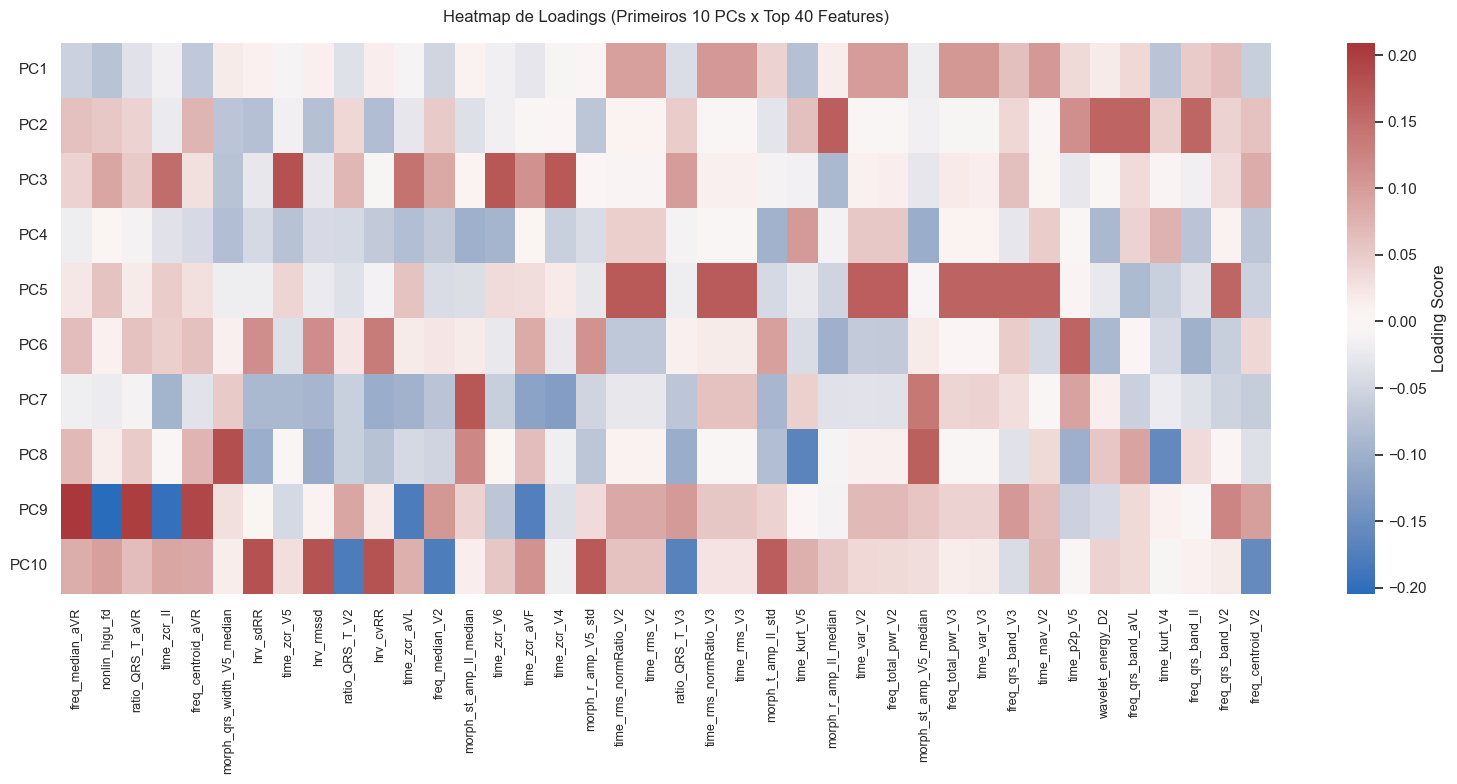

=== TOP 5 Features de maior Loading em PC1 a PC5 ===
PC1: time_mav_III (0.11), time_mav_V3 (0.11), time_mav_V1 (0.11), time_mav_aVF (0.11), time_var_V3 (0.11)
PC2: morph_r_amp_II_median (0.17), wavelet_energy_D2 (0.16), freq_qrs_band_aVL (0.16), freq_qrs_band_II (0.16), morph_r_amp_V5_median (0.15)
PC3: time_zcr_V5 (0.18), time_zcr_V6 (0.17), time_zcr_V4 (0.17), time_zcr_V3 (0.15), time_zcr_II (0.15)
PC4: time_skew_aVR (0.15), time_p2p_I (0.14), time_rms_I (0.14), time_rms_normRatio_I (0.14), time_skew_I (0.14)
PC5: time_rms_normRatio_V2 (0.17), time_rms_V2 (0.17), time_rms_normRatio_V3 (0.17), time_rms_V3 (0.17), time_var_V2 (0.17)


**(Espaço para comentário do aluno — o que o PC1 está capturando fisicamente das frequências/amplitudes?)**

In [17]:
loadings = pca_full.components_[:10, :]  # shape: (10, n_features)

# Selecionamos apenas features que tiveram alta relevância na formulação
abs_loadings = np.abs(loadings)
max_weights = np.max(abs_loadings, axis=0)

# Filtrar as top 40 features em influência geral (pra caber no plot)
top_idx = max_weights.argsort()[-40:][::-1]
features_subset = [feature_cols[i] for i in top_idx]
loadings_subset = loadings[:, top_idx]

plt.figure(figsize=(16, 8))
sns.heatmap(loadings_subset, cmap='vlag', center=0, 
            yticklabels=[f"PC{i+1}" for i in range(10)],
            xticklabels=features_subset, cbar_kws={'label': 'Loading Score'})
plt.title('Heatmap de Loadings (Primeiros 10 PCs x Top 40 Features)', pad=15)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'pca_loadings.png'), dpi=150)
plt.show()

# Para cada um dos 5 primeiros, listar no log textual
print("=== TOP 5 Features de maior Loading em PC1 a PC5 ===")
for i in range(5):
    idx_top5 = np.abs(loadings[i]).argsort()[-5:][::-1]
    res_str = ", ".join([f"{feature_cols[j]} ({loadings[i][j]:.2f})" for j in idx_top5])
    print(f"PC{i+1}: {res_str}")

display(Markdown("**(Espaço para comentário do aluno — o que o PC1 está capturando fisicamente das frequências/amplitudes?)**"))

### 2.4 Visualização do Espaço dos Primeiros PCs (Elipses de Confiança)
Para entender se o PCA conseguiu, marginalmente em 2D, criar clusters entre as superclasses diagnósticas, plotaremos pares bi-dimensionais.

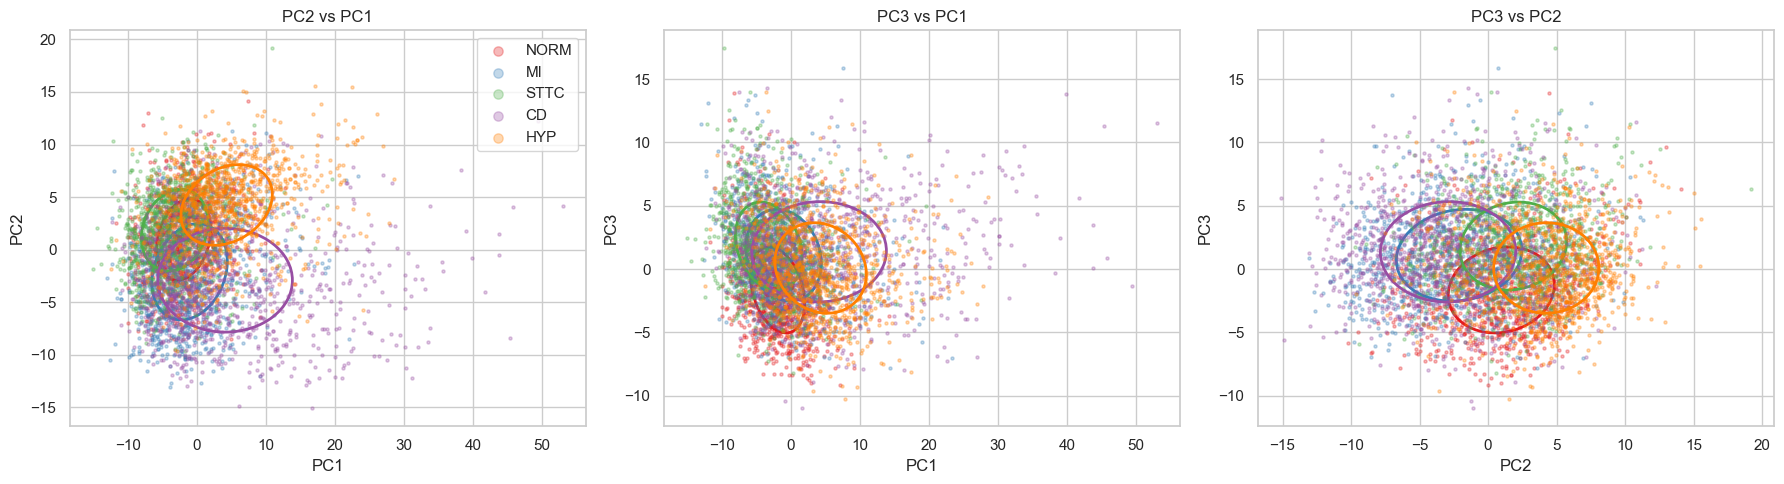

**(Espaço para comentário do aluno — o alto Overlap visual entre as elipses sugere que as superclasses de ECG não são problemas lineares bi-dimensionais. Isso reforça a necessidade de reter em torno de 95% da variância.)**

In [18]:
def confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)
    
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    
    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(np.mean(x), np.mean(y))
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

pca_top3 = pca_full.transform(X_all_std)[:, :3]

df_plot = df[['label_primary']].copy()
df_plot['PC1'] = pca_top3[:, 0]
df_plot['PC2'] = pca_top3[:, 1]
df_plot['PC3'] = pca_top3[:, 2]

# Remove rótulos residuais 'UNKNOWN'
df_plot = df_plot[df_plot['label_primary'] != 'UNKNOWN']
classes_target = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
paleta = sns.color_palette("Set1", len(classes_target))
color_map = dict(zip(classes_target, paleta))

pares = [('PC1', 'PC2'), ('PC1', 'PC3'), ('PC2', 'PC3')]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (pc_x, pc_y) in enumerate(pares):
    ax = axes[i]
    for c in classes_target:
        mask_c = df_plot['label_primary'] == c
        # Limita pontos por desempenho 
        pts = df_plot[mask_c].sample(min(1000, mask_c.sum()), random_state=42)
        ax.scatter(pts[pc_x], pts[pc_y], s=5, alpha=0.3, color=color_map[c], label=c)
        try:
            confidence_ellipse(df_plot.loc[mask_c, pc_x], df_plot.loc[mask_c, pc_y], ax,
                               n_std=1, edgecolor=color_map[c], lw=2)
        except Exception:
            pass # matriz singular/ignorar
    ax.set_title(f'{pc_y} vs {pc_x}')
    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)

axes[0].legend(loc='best', markerscale=3)
plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'pca_elipses_dispersao.png'), dpi=150)
plt.show()

display(Markdown("**(Espaço para comentário do aluno — o alto Overlap visual entre as elipses sugere que as superclasses de ECG não são problemas lineares bi-dimensionais. Isso reforça a necessidade de reter em torno de 95% da variância.)**"))

### 2.5 Instanciação do Modelo Final e Transformação
Vamos solidificar no objetivo de Reter **95%**.

In [19]:
k_95 = cortes_k[95]
print(f"Aplicando corte padrão de retenção em K={k_95} (95% da variância explicada).")

pca_final = PCA(n_components=k_95, random_state=42)
pca_final.fit(X_treino_std)

X_all_pca = pca_final.transform(X_all_std)

# Gerar o df
cols_pca = [f"PC{i+1}" for i in range(k_95)]
df_pca = pd.DataFrame(X_all_pca, columns=cols_pca, index=df.index)

# Juntar os metadados de volta
df_pca = df[meta_cols].join(df_pca)
print(f"Dataset PCA transformado: {df_pca.shape}")

Aplicando corte padrão de retenção em K=68 (95% da variância explicada).
Dataset PCA transformado: (21735, 73)


---
## Seção 3 — ICA (Independent Component Analysis)

Enquanto o PCA maximiza a variância sob restrição ortogonal, o ICA busca independência estatística nas variáveis combinadas (sem forçar ortogonalidade), assumindo sinais fonte "não-Gaussianos". Ele é muito forte para identificação e segregação de ruídos remanescentes.

### 3.1 Projeção Local no Domínio PCA
O FastICA tem dificuldades de convergir em grandes dimensões de colinearidade forte. A técnica clássica é submetê-lo sobre as respostas do PCA anterior.

In [20]:
print("Aplicando FastICA no Top 20 Componentes...")
n_ica = min(20, k_95)

ica = FastICA(n_components=n_ica, random_state=42, max_iter=800)
# Fit apenas no Treino (na base transformada pca std)
X_treino_pca = pca_final.transform(X_treino_std)
ica.fit(X_treino_pca[:, :n_ica])

X_all_ica = ica.transform(X_all_pca[:, :n_ica])

cols_ica = [f"IC{i+1}" for i in range(n_ica)]
df_ica_temp = pd.DataFrame(X_all_ica, columns=cols_ica, index=df.index)

print(f"Matriz ICA Computada: {df_ica_temp.shape}")

Aplicando FastICA no Top 20 Componentes...
Matriz ICA Computada: (21735, 20)


### 3.2 Correlação com Qualidade de Origem (SQI)
Para saber se algum Componente Independente separou exclusivamente o ruído.

,Correlacao_Pearson_com_SQI
IC11,0.335765
IC7,0.119950
IC9,0.100200
IC13,0.099618
IC12,0.048734


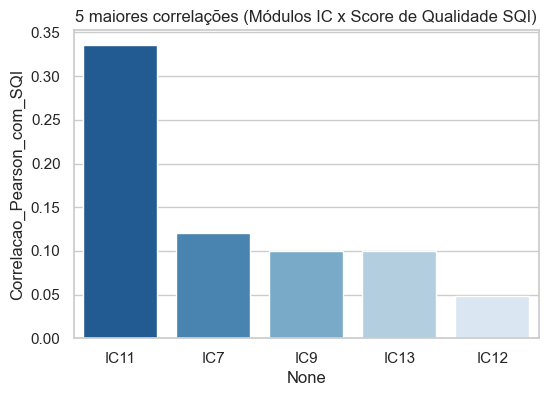

**(Espaço para comentário do aluno — Se algum IC apresenta forte correlação (> 0.5) com o SQI, isso sugere que sua variância é quase toda de degradação residual e pode ser um ótimo indício de descarte. Analise o que os números estão mostrando.)**

In [21]:
df_sqi_join = df[['sqi_score', 'sqi_category']].join(df_ica_temp)

corrs_sqi = df_sqi_join[cols_ica].apply(lambda col: col.corr(df_sqi_join['sqi_score']))
df_corrs_ica = pd.DataFrame(corrs_sqi, columns=['Correlacao_Pearson_com_SQI']).sort_values(by='Correlacao_Pearson_com_SQI', ascending=False)

display(df_corrs_ica.head(5))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=df_corrs_ica.index[:5], y=df_corrs_ica['Correlacao_Pearson_com_SQI'][:5], ax=ax, palette='Blues_r')
ax.set_title("5 maiores correlações (Módulos IC x Score de Qualidade SQI)")
plt.show()

display(Markdown("**(Espaço para comentário do aluno — Se algum IC apresenta forte correlação (> 0.5) com o SQI, isso sugere que sua variância é quase toda de degradação residual e pode ser um ótimo indício de descarte. Analise o que os números estão mostrando.)**"))

---
## Seção 4 — Síntese e Conexão

Neste notebook, abordamos os métodos formativos de separação latente:
1. Verificamos a necessidade de redução de dimensões.
2. Formamos e exportamos os componentes explicativos globais utilizando o PCA (Retendo 95% da variância).
3. Testamos analiticamente uma quebra em Fontes Independentes (ICA) baseada no SQI do segundo estágio do projeto.

A seleção formal de atributos preservacionista que manterá a semântica nativa (Entregável 9) **utilizará a tabela anterior do Entregável 7**. Os artefatos criados aqui mantêm a frente investigativa baseada exclusivamente em modelagens de Distância espacial que exijam vetores reduzidos sem significado clínico nativo por coordenada.

In [22]:
pca_pipeline = {
    'scaler': scaler_pca,
    'pca_model': pca_final,
    'k_95': k_95,
    'ica_model': ica
}

modelo_path = os.path.join(DIR_OUT_D8, 'pca_model.pkl')
joblib.dump(pca_pipeline, modelo_path)

df_pca.to_parquet(os.path.join(DIR_OUT_D8, 'features_pca.parquet'))

print(f"Artefatos Válidos Persistidos:\n- {modelo_path} (Pipeline Treino)\n- features_pca.parquet (Dims base K={k_95})")

Artefatos Válidos Persistidos:
- ../outputs/pca_model.pkl (Pipeline Treino)
- features_pca.parquet (Dims base K=68)
